목표

*   pdb 구조 서열 추출
*   protein-ligand 분리
*   3D 좌표 -> distance map

In [3]:
from google.colab import drive

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd "/content/drive/MyDrive/

/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/중급 강의 노트/단백질 구조 기반 약물탐색/2. PDB 분석


In [11]:
!unzip exercise_pdb1.zip

Archive:  exercise_pdb1.zip
  inflating: 0_실습환경설정_conda_설정.pptx  
  inflating: 0_실습환경설정_wsl_설치.pptx  
  inflating: exercise_pdb.zip        
  inflating: Format_v33_A4.pdf       
  inflating: PBI.zip                 
  inflating: TGFR1.zip               
  inflating: TGFR1_test.zip          


In [14]:
!unzip TGFR1.zip
!unzip TGFR1_test.zip

Archive:  TGFR1.zip
  inflating: auto_box.sh             
  inflating: auto_run.sh             
  inflating: autobox.txt             
   creating: chain/
  inflating: chain/1B6CA.pdb         
  inflating: chain/1B6CB.pdb         
  inflating: chain/1B6CB_HOH.pdb     
  inflating: chain/1B6CB_receptor.pdb  
  inflating: chain/1B6CB_rotate.pdb  
  inflating: chain/1B6CB_SO4.pdb     
  inflating: chain/1B6CC.pdb         
  inflating: chain/1B6CD.pdb         
  inflating: chain/1B6CE.pdb         
  inflating: chain/1B6CF.pdb         
  inflating: chain/1B6CG.pdb         
  inflating: chain/1B6CH.pdb         
  inflating: chain/1IASA.pdb         
  inflating: chain/1IASA_receptor.pdb  
  inflating: chain/1IASA_rotate.pdb  
  inflating: chain/1IASA_SO4.pdb     
  inflating: chain/1IASB.pdb         
  inflating: chain/1IASC.pdb         
  inflating: chain/1IASD.pdb         
  inflating: chain/1IASE.pdb         
  inflating: chain/1PY5A.pdb         
  inflating: chain/1PY5A_HOH.pdb     
  infl

In [7]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.0 MB/s eta 0:00:00


# 1. pdb 구조 서열 추출 실습

In [ ]:
"""# PDB 파일 서열(SEQRES) 추출 파이썬 코드

구글 코랩 환경에서 Biopython을 활용하여 PDB 파일의 서열(SEQRES)을 추출하는 코드입니다.
아래 코드를 복사하여 코랩의 새 셀에 붙여넣고 실행해 보세요.

## 1. SeqIO 모듈을 이용한 SEQRES 서열 추출 (가장 추천)
`Bio.SeqIO`를 사용하면 PDB 파일 내의 `SEQRES` 레코드를 아주 빠르고 간단하게 파싱할 수 있습니다. `exercise_pdb.zip` 압축 해제 후 나온 PDB 파일 중 하나의 이름을 입력하여 테스트해 보세요.


In [8]:
from Bio import SeqIO
import os

# 실습할 PDB 파일 이름을 지정해 주세요 (예: '1abc.pdb')
pdb_file = 'pdb/3HMM.pdb'

if not os.path.exists(pdb_file):
    print(f"현재 폴더에 {pdb_file} 파일이 없습니다. 파일 이름을 다시 확인해 주세요.")
else:
    print(f"[{pdb_file}] SEQRES 서열 추출 결과:\\n")
    # 'pdb-seqres' 포맷을 지정하면 SEQRES 정보를 읽어옵니다.
    for record in SeqIO.parse(pdb_file, "pdb-seqres"):
        chain_id = record.annotations['chain']
        sequence = record.seq

        print(f">Chain {chain_id} (길이: {len(sequence)} aa)")
        print(sequence)
        print("-" * 50)

[pdb/3HMM.pdb] SEQRES 서열 추출 결과:\n
>Chain A (길이: 303 aa)
IARTIVLQESIGKGRFGEVWRGKWRGEEVAVKIFSSREERSWFREAEIYQTVMLRHENILGFIAADNKDNGTWTQLWLVSDYHEHGSLFDYLNRYTVTVEGMIKLALSTASGLAHLHMEIVGTQGKPAIAHRDLKSKNILVKKNGTCCIADLGLAVRHDSATDTIDIAPNHRVGTKRYMAPEVLDDSINMKHFESFKRADIYAMGLVFWEIARRCSIGGIHEDYQLPYYDLVPSDPSVEEMRKVVCEQKLRPNIPNRWQSCEALRVMAKIMRECWYANGAARLTALRIKKTLSQLSQQEGIKM
--------------------------------------------------


In [ ]:
#위의 1번 코드는 단백질의 '원래 전체 서열(SEQRES)'을 가져오는 것이고, 아래 코드는 3D 구조 실험에서 '실제로 좌표가 관측된(ATOM) 서열'만 이어 붙여서 가져옵니다. 두 서열의 길이를 비교해 보면 누락된 잔기가 있는지 확인할 수 있습니다.

In [9]:
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import PPBuilder

pdb_file = 'pdb/3HMM.pdb'

if os.path.exists(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)
    ppb = PPBuilder()

    print(f"[{pdb_file}] ATOM 기반 서열 추출 결과:\\n")
    # 폴리펩타이드 체인을 만들어주는 PPBuilder 사용
    for idx, pp in enumerate(ppb.build_peptides(structure)):
        sequence = pp.get_sequence()
        print(f">Fragment {idx+1} (길이: {len(sequence)} aa)")
        print(sequence)
        print("-" * 50)

[pdb/3HMM.pdb] ATOM 기반 서열 추출 결과:\n
>Fragment 1 (길이: 168 aa)
IARTIVLQESIGKGRFGEVWRGKWRGEEVAVKIFSSREERSWFREAEIYQTVMLRHENILGFIAADNKDNGTWTQLWLVSDYHEHGSLFDYLNRYTVTVEGMIKLALSTASGLAHLHMEIVGTQGKPAIAHRDLKSKNILVKKNGTCCIADLGLAVRHDSATDTIDIA
--------------------------------------------------
>Fragment 2 (길이: 125 aa)
GTKRYMAPEVLDDSINMKHFESFKRADIYAMGLVFWEIARRCSIGGIHEDYQLPYYDLVPSDPSVEEMRKVVCEQKLRPNIPNRWQSCEALRVMAKIMRECWYANGAARLTALRIKKTLSQLSQQ
--------------------------------------------------


두 결과를 비교해 보면 3D 구조 데이터의 불완전성을 명확히 파악할 수 있다.


*   전체 서열 (SEQRES): 실험에 사용된 단백질의 원래 길이는 303개입니다.
*   관측된 서열 (ATOM): 3D 좌표가 실제로 존재하는 아미노산은 총 293개(168 + 125)이며, 서열이 하나로 이어지지 못하고 2개의 조각(Fragment)으로 나뉘었습니다.
*   사라진 10개의 아미노산은 단백질에서 잘려 나간 것이 아니라, 유연하게 흔들려서 3D 카메라(X선)에 좌표가 찍히지 않은 부분입니다. 원래 서열과 대조해 보면 누락된 위치를 정확히 찾을 수 있습니다.
*   중간 루프(Loop) 영역 누락 (5개): Fragment 1의 끝(...IDIA)과 Fragment 2의 시작(GTKRY...) 사이를 SEQRES 서열에서 찾아보면 PNHRV가 빠져 있습니다. 이 부위의 구조를 파악하지 못해 서열이 두 동강 난 것처럼 출력된 것입니다.
*   C-말단 꼬리 영역 누락 (5개): SEQRES는 ...LSQQEGIKM으로 끝나지만, Fragment 2는 ...LSQQ로 끝납니다. 끝부분에 덜렁거리는 꼬리인 EGIKM의 좌표 역시 관측되지 않았습니다.











In [10]:
from Bio import SeqIO
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import PPBuilder
import os

pdb_file = 'pdb/3HMM.pdb'

if os.path.exists(pdb_file):
    # 1. SEQRES (전체 서열) 추출
    seqres_dict = {record.annotations['chain']: str(record.seq)
                   for record in SeqIO.parse(pdb_file, "pdb-seqres")}
    full_sequence = seqres_dict.get('A', '') # Chain A 기준

    # 2. ATOM (관측된 조각 서열) 추출
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('3HMM', pdb_file)
    ppb = PPBuilder()

    # Chain A의 폴리펩타이드 조각들 가져오기
    chain_a = structure[0]['A']
    fragments = [str(pp.get_sequence()) for pp in ppb.build_peptides(chain_a)]

    # 3. 서열 대조 및 누락 영역 탐색
    print("=== 서열 대조 분석 결과 ===")
    print(f"전체 서열 길이 (SEQRES): {len(full_sequence)} aa")

    current_search_index = 0

    for i, frag in enumerate(fragments):
        # 전체 서열 안에서 현재 조각(Fragment)이 시작하는 위치를 찾음
        frag_start_index = full_sequence.find(frag, current_search_index)

        # 탐색 시작 위치와 조각 시작 위치가 다르다면, 그 사이에 누락된 서열이 존재함
        if frag_start_index > current_search_index:
            missing_seq = full_sequence[current_search_index:frag_start_index]
            print(f"\n[!] 누락 발견: Fragment {i} 앞부분 (길이: {len(missing_seq)} aa)")
            print(f"누락된 아미노산: {missing_seq}")

        print(f"-> Fragment {i+1} 매칭 완료 (길이: {len(frag)} aa)")
        # 다음 탐색 위치를 현재 조각이 끝난 지점으로 갱신
        current_search_index = frag_start_index + len(frag)

    # 마지막 조각 이후에 남은 서열이 있다면 C-말단 누락임
    if current_search_index < len(full_sequence):
        missing_seq = full_sequence[current_search_index:]
        print(f"\n[!] 누락 발견: C-말단 꼬리 영역 (길이: {len(missing_seq)} aa)")
        print(f"누락된 아미노산: {missing_seq}")

=== 서열 대조 분석 결과 ===
전체 서열 길이 (SEQRES): 303 aa
-> Fragment 1 매칭 완료 (길이: 168 aa)

[!] 누락 발견: Fragment 1 앞부분 (길이: 5 aa)
누락된 아미노산: PNHRV
-> Fragment 2 매칭 완료 (길이: 125 aa)

[!] 누락 발견: C-말단 꼬리 영역 (길이: 5 aa)
누락된 아미노산: EGIKM


단백질 구조 데이터(PDB)에서 루프(Loop) 영역과 양 끝단(N-말단, C-말단) 꼬리 부분이 누락되는 것은 매우 흔하고 자연스러운 현상이다.
*   말단 꼬리 (N-말단 및 C-말단): 단백질 펩타이드 사슬의 시작과 끝부분으로, 양쪽이 꽉 붙잡힌 중간 부위들과 달리 한쪽 끝이 허공을 향해 열려 있습니다. 뼈대를 지탱해 주는 구조적 제약이 없어 채찍처럼 매우 자유롭게 움직이므로, 구조가 누락되는 가장 대표적인 부위입니다.
*   루프 (Loop) 영역: 단단하고 규칙적인 알파 나선(Alpha-helix)이나 베타 병풍(Beta-sheet) 같은 2차 구조들을 끈처럼 연결해 주는 관절 역할을 합니다. 특히 효소의 활성 부위나 항체의 결합 부위(CDR)에 존재하는 루프들은 표적 물질과 결합하기 위해 본질적으로 모양을 이리저리 바꿀 수 있어야 하므로 관측이 매우 까다롭습니다.

<br>
해결 방안

*   이러한 한계 때문에 구조 생물정보학에서는 실험적으로 보이지 않는 이 유연한 루프와 꼬리의 3차원 구조를 파이썬과 같은 컴퓨터 알고리즘으로 예측하여 원래 서열(SEQRES)에 맞게 억지로 채워 넣는 '**루프 모델링(Loop modeling)**' 혹은 '**구조 복원**' 과정이 단백질 전처리 단계에서 매우 중요하게 다루어집니다.





### +) 루프 모델링

누락된 루프를 복원하는 작업은 단순한 선 긋기가 아니라 단백질이 뭉치는 물리화학적 에너지를 계산해야 하므로, 전문적인 구조 예측 패키지를 사용해야 합니다. 현재 파이썬 및 코랩 환경과 연계하여 가장 널리 쓰이는 대표적인 도구들은 다음과 같습니다.
*   MODELLER (모델러): 파이썬 스크립트 기반으로 구동되는 가장 고전적이고 표준적인 상동 모델링(Homology Modeling) 프로그램입니다. 불완전한 PDB 파일과 원래의 전체 서열(SEQRES)을 함께 입력하면, 빈 공간의 뼈대를 이어 붙인 뒤 에너지적으로 가장 안정한 루프 구조를 계산해 여러 개의 후보군을 만들어 냅니다. 학술 목적으로 라이선스 키를 무료로 발급받아 코랩 환경에서도 설치해 구동할 수 있습니다.
*   PyRosetta (파리로제타): 단백질 구조 예측 및 디자인 분야의 강력한 소프트웨어인 Rosetta를 파이썬에서 제어할 수 있게 만든 패키지입니다. 내부적으로 루프 모델링 전용 클래스(LoopMover 등)를 지원하며, 수만 번의 구조적 비틀림 시뮬레이션을 통해 텅 빈 공간에서 물리적으로 가장 타당한 루프 형태를 정밀하게 예측(Ab initio modeling)하는 데 탁월합니다.
*   **AlphaFold2 (ColabFold 활용)**: 최근 신약 개발 현장에서 가장 많이 사용하는 딥러닝 기반 접근법입니다. 듬성듬성 구멍이 난 기존 PDB 파일을 억지로 깁는 대신, 앞서 추출하셨던 전체 아미노산 서열(SEQRES) 자체를 구글 코랩에 최적화된 ColabFold에 입력합니다. 그러면 AI가 누락되었던 루프와 꼬리 부분까지 모두 포함된 완전하고 정확한 3D 구조를 통째로 새롭게 예측하여 .pdb 파일로 반환해 줍니다.
*   빠르고 현대적인 워크플로우를 원하신다면, 결함이 있는 실험 구조(X-ray PDB)의 뼈대만 참고하고 누락된 부위는 ColabFold를 통해 새로 예측된 구조로 대체하여 후속 약물 결합 분석(Docking)을 진행하는 방식을 가장 추천합니다.













In [11]:
!pip install -q "colabfold[alphafold] @ git+https://github.com/sokrypton/ColabFold"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.1/264.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.4 MB/s eta 0:00:00


In [12]:
fasta_content = """>3HMM_Target_Sequence
IARTIVLQESIGKGRFGEVWRGKWRGEEVAVKIFSSREERSWFREAEIYQTVMLRHENILGFIAADNKDNGTWTQLWLVSDYHEHGSLFDYLNRYTVTVEGMIKLALSTASGLAHLHMEIVGTQGKPAIAHRDLKSKNILVKKNGTCCIADLGLAVRHDSATDTIDIAPNHRVGTKRYMAPEVLDDSINMKHFESFKRADIYAMGLVFWEIARRCSIGGIHEDYQLPYYDLVPSDPSVEEMRKVVCEQKLRPNIPNRWQSCEALRVMAKIMRECWYANGAARLTALRIKKTLSQLSQQEGIKM"""

with open("3HMM_target.fasta", "w") as f:
    f.write(fasta_content)
print("FASTA 파일 생성 완료.")

FASTA 파일 생성 완료.


In [13]:
# --num-recycle 3: AI 구조 개선 반복 횟수 (정밀도 향상)
!colabfold_batch 3HMM_target.fasta ./alphafold_output --num-recycle 3

/usr/local/lib/python3.13/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.11.1 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(
2026-09-09 08:27:08,998 Running colabfold 1.6.2 (c35de0221f4d297a39edf4cf292ba2832e321edc)

limited shared resource only capable of processing a few thousand MSAs per day. Please
submit jobs only from a single IP address. We reserve the right to limit access to the
server case-by-case when usage exceeds fair use. If you require more MSAs: You can 
precompute all MSAs with `colabfold_search` or host your own API and pass it to `--host-url`

2026-09-09 08:27:28,844 Running on GPU
2026-09-09 08:27:29,973 Found 5 citations for tools or databases
2026-09-09 08:27:29,974 Query 1/1: 3HMM_Target_Sequence (length 303)
2026-09-09 08:27:34,683 Setting max_seq=512, max_extra_seq=5120
2026-09-09 08:28:39,004 alphafold2_ptm_model_1_seed_000 recycle=0 pL



1. **파일 불러오기:** 로컬 PC에서 파이몰(PyMOL)을 실행한 후, 상단 메뉴의 **File -> Open**을 클릭하거나 탐색기에서 파일을 파이몰 화면으로 드래그 앤 드롭하여 두 개의 파일을 모두 엽니다. 우측 오브젝트 패널에 `3HMM_protein`과 `3HMM_Target_Sequence_unrelaxed_rank_001`이 각각 생성된 것을 확인합니다.
2. **단백질 겹치기 (Align):** 파이몰 화면 상단이나 하단에 있는 명령창(PyMOL> 프롬프트)에 아래의 정렬 명령어를 입력하고 엔터를 칩니다. (AI가 예측한 구조를 기준이 되는 원본 구조에 덧씌우는 작업입니다.)
`align 3HMM_Target_Sequence_unrelaxed_rank_001, 3HMM_protein`
3. **색상 변경으로 대비 주기:** 두 구조가 겹쳐지면 헷갈릴 수 있으므로 구분을 위해 색상을 바꿉니다. 우측 패널에서 각 오브젝트 이름 옆의 **[C] (Color)** 버튼을 누릅니다.
* `3HMM_protein`은 회색(grays -> gray70) 등 옅은 색으로 지정합니다.
* `3HMM_Target_...rank_001`은 청록색(cyans -> cyan) 등 튀는 색으로 지정합니다.
4. **누락된 루프 및 꼬리 확인:** 명령창에 아래 명령어를 입력하여 AI가 복원한 169~173번 잔기와 C-말단 부위로 카메라를 줌인합니다.
`select missing_parts, resi 169-173+299-303`
`zoom missing_parts`
5. **결과 관찰:** 회색 뼈대(원본)는 해당 부위에서 끊어져 허공에 떠 있는 반면, 청록색 뼈대(AI 예측)는 끊어진 두 지점을 잇는 완벽한 루프 형태(PNHRV)와 끝부분의 꼬리(EGIKM)를 매끄럽게 연결하고 있는 모습을 3D로 돌려가며 확인할 수 있습니다.



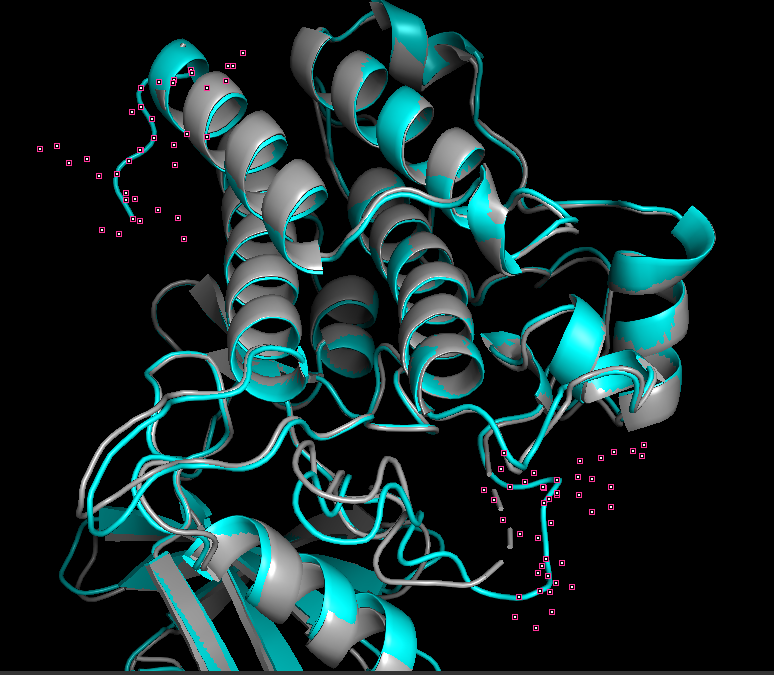

# 2. 단백질(ATOM)과 리간드(HETATM) 분리 작업 실습

In [19]:
#PDB 파일에서 물 분자를 제외하고 순수한 단백질 뼈대와 결합된 리간드(약물)만 각각의 파일로 쪼개어 저장하는 코드

from Bio.PDB import PDBParser, Select, PDBIO
import os

pdb_file = 'pdb/3HMM.pdb'

# 1. 단백질(표준 아미노산)만 통과시키는 필터
class ProteinSelect(Select):
    def accept_residue(self, residue):
        # residue.id[0]이 공백(' ')이면 표준 아미노산(ATOM)을 의미합니다.
        return residue.id[0] == ' '

# 2. 리간드만 통과시키는 필터
class LigandSelect(Select):
    def accept_residue(self, residue):
        # 'H_'로 시작하는 것은 헤테로 원자(HETATM) 중 리간드를 의미합니다.
        # (물 분자는 'W'로 표시되므로 자연스럽게 제외됨)
        return residue.id[0].startswith('H_')

if not os.path.exists(pdb_file):
    print("PDB 파일을 찾을 수 없습니다. 경로를 확인해 주세요.")
else:
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('3HMM', pdb_file)
    io = PDBIO()
    io.set_structure(structure)

    # 단백질 분리 및 저장
    protein_file = '3HMM_protein.pdb'
    io.save(protein_file, ProteinSelect())
    print(f"✅ 단백질만 추출하여 [{protein_file}] 파일로 저장했습니다.")

    # 리간드 분리 및 저장
    ligand_file = '3HMM_ligand.pdb'
    io.save(ligand_file, LigandSelect())
    print(f"✅ 리간드만 추출하여 [{ligand_file}] 파일로 저장했습니다.")

✅ 단백질만 추출하여 [3HMM_protein.pdb] 파일로 저장했습니다.
✅ 리간드만 추출하여 [3HMM_ligand.pdb] 파일로 저장했습니다.


# 3. 3D 좌표 -> distance map
단백질 3차원 구조의 뼈대를 대표하는 알파 탄소(CA) 좌표를 추출하여 아미노산 간의 유클리디안 거리를 계산하고, 이를 히트맵(Heatmap) 형태의 Distance Map으로 시각화하는 파이썬 코드

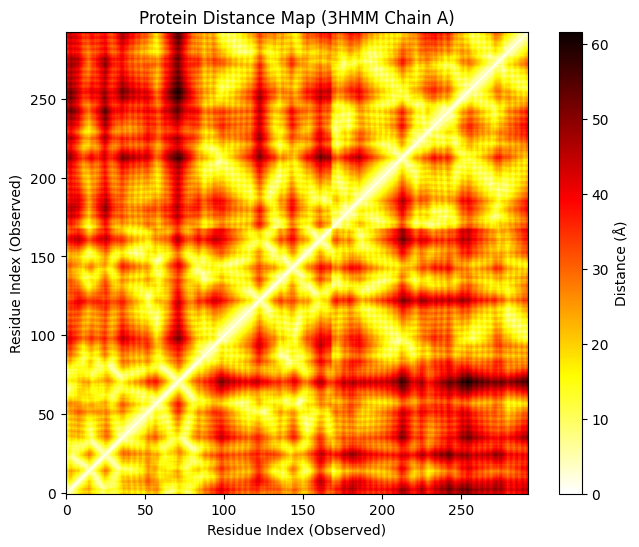

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser
from scipy.spatial import distance_matrix

# 1. PDB 파일 로드 및 알파 탄소(CA) 좌표 추출
parser = PDBParser(QUIET=True)
# 앞서 분리한 단백질 전용 파일 사용
structure = parser.get_structure('3HMM_protein', '3HMM_protein.pdb')

ca_coords = []
# Chain A에 속한 표준 아미노산의 CA 원자 좌표만 수집
for residue in structure[0]['A']:
    if residue.id[0] == ' ' and 'CA' in residue:
        ca_coords.append(residue['CA'].get_coord())

# NumPy 배열로 변환 (N x 3 행렬)
coords_array = np.array(ca_coords)

# 2. 아미노산 간의 유클리디안 거리 행렬 계산
# 모든 CA 원자 쌍(Pair) 간의 물리적 거리(Å, 옹스트롬)를 계산
dist_matrix = distance_matrix(coords_array, coords_array)

# 3. Distance Map (히트맵) 시각화
plt.figure(figsize=(8, 6))
# 거리가 가까울수록 붉은색/짙은색 계열로 표시되도록 cmap 지정
plt.imshow(dist_matrix, cmap='hot_r', origin='lower')
plt.colorbar(label='Distance (Å)')
plt.title('Protein Distance Map (3HMM Chain A)')
plt.xlabel('Residue Index (Observed)')
plt.ylabel('Residue Index (Observed)')
plt.show()


*   단백질의 밀집도: 좌측 하단에서 우측 상단으로 이어지는 흰색 대각선(거리 0Å)을 중심으로 밝은 색상이 넓게 퍼진 덩어리 형상들은 아미노산들이 국소적으로 조밀하게 뭉쳐 있는 독립적인 구조적 도메인(Domain)들의 경계임을 알 수 있다.



## +) py3Dmol: 코랩 내부에 3D 뷰어 띄우기
단백질 구조를 무지개색 카툰(Cartoon) 모델로 렌더링하여 마우스로 줌인/아웃 및 회전할 수 있도록 띄워줍니다.

In [20]:
# 패키지 설치 (최초 1회)
!pip install py3Dmol

In [21]:


import py3Dmol

# 앞서 분리해둔 단백질 PDB 파일 읽기
with open("3HMM_protein.pdb") as f:
    pdb_data = f.read()

# 3D 뷰어 생성 및 설정
view = py3Dmol.view(width=800, height=500)
view.addModel(pdb_data, 'pdb')

# 단백질 뼈대를 카툰 형식으로 스펙트럼 색상 적용
view.setStyle({'model': -1}, {'cartoon': {'color': 'spectrum'}})

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## +) Biotite: 8Å 기준 Contact Map (접촉 지도) 그리기
모든 거리를 색상으로 보여주던 앞선 히트맵과 달리, 특정 거리(예: 8Å) 이내로 가까워 물리적으로 상호작용할 가능성이 높은 잔기 쌍들만 흑백(True/False)으로 깔끔하게 필터링하여 보여줍니다.

In [22]:
# 패키지 설치 (최초 1회)
!pip install biotite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.9 MB/s eta 0:00:00


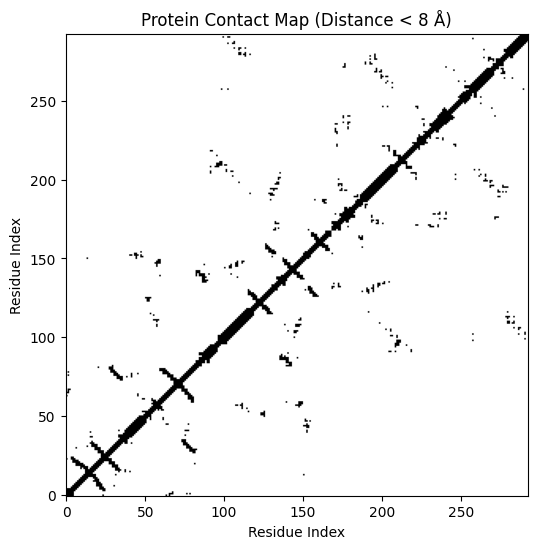

In [23]:


import biotite.structure.io as strucio
import biotite.structure as struc
import matplotlib.pyplot as plt

# Biotite를 이용한 빠른 PDB 로드
protein = strucio.load_structure("3HMM_protein.pdb")

# 알파 탄소(CA)만 추출
ca_atoms = protein[protein.atom_name == "CA"]

# 임계값(8.0 옹스트롬)을 기준으로 인접 행렬(Adjacency matrix) 생성
# 거리가 8Å 이내면 1(검은색), 밖이면 0(흰색)으로 처리됨
cell_list = struc.CellList(ca_atoms, cell_size=8.0)
contact_matrix = cell_list.create_adjacency_matrix(8.0)

# 시각화
plt.figure(figsize=(6, 6))
plt.imshow(contact_matrix, cmap='Greys', origin='lower')
plt.title('Protein Contact Map (Distance < 8 Å)')
plt.xlabel('Residue Index')
plt.ylabel('Residue Index')
plt.show()



*   핵심 상호작용망 필터링: 거리가 8Å 미만인 인접 잔기 쌍만 검은색 점으로 표시하여, 거리가 먼 노이즈를 제거하고 실제 물리적 결합(수소결합, 반데르발스 힘 등)을 형성할 가능성이 높은 유의미한 접촉만 선명하게 드러냅니다.
*   **2차 구조(Secondary Structure) 패턴**: 대각선을 따라 두껍게 칠해진 연속적인 선형 패턴은 인접한 잔기들이 나선형으로 꼬이며 밀착하는 알파 나선(Alpha-helix) 구조를 나타냅니다. 반면, 대각선과 동떨어진 위치에서 나란히 혹은 수직으로 나타나는 선형 점들은 베타 병풍(Beta-sheet)을 형성하며 서로 맞닿은 가닥들을 보여줍니다.
*   원거리 3차 접힘(Tertiary Structure): 서열 인덱스 상으로는 수십 번 이상 멀리 떨어져 있음에도 8Å 이내로 인접하여 대각선 바깥 영역에 점으로 찍힌 곳들은 단백질이 3차원 구형으로 접히면서 맞물린 핵심 골조입니다. 구조 기반 신약 탐색 시 이 지점들은 단백질의 구조적 안정성을 결정하거나 약물이 결합하는 주요 활성 포켓일 확률이 매우 높습니다.








